Feature extraction refers to the process of selecting and transforming raw data into numerical features that can be used by machine learning models. It is commonly used when dealing with high-dimensional data, such as images, text, and sensor data.

Example:

- In text data, extracting word embeddings like TF-IDF or Word2Vec.
- In images, extracting edges and textures using convolution filters.

#  Why is Feature Extraction Important?
- Reduces data dimensionality, making computations faster.
- Removes irrelevant or redundant information.
- Improves model interpretability and accuracy.
- Helps in handling complex and unstructured data (e.g., text, images, audio).

# Types of Feature Extraction Techniques
Feature extraction varies depending on the type of data (numerical, text, image, or audio). Below are some common techniques:

## A. Feature Extraction for Numerical Data
- Principal Component Analysis (PCA): Reduces dimensionality while preserving variance.
- Linear Discriminant Analysis (LDA): Maximizes class separability.
- Polynomial Features: Expands features using polynomial terms.
- Fourier Transform: Converts time-series data into frequency components.

## B. Feature Extraction for Text Data
- Bag of Words (BoW): Represents text as a frequency vector.

- TF-IDF (Term Frequency-Inverse Document Frequency): Assigns importance to words based on frequency and uniqueness.

- Word Embeddings (Word2Vec, GloVe, FastText): Converts words into dense vector representations.



## C. Feature Extraction for Image Data
- Histogram of Oriented Gradients (HOG): Detects object shapes.

- SIFT (Scale-Invariant Feature Transform): Identifies key points in an image.

- CNN (Convolutional Neural Networks): Extracts features automatically from image layers.

- Color Histograms: Represents image color distribution.

## D. Feature Extraction for Audio Data
- Mel Frequency Cepstral Coefficients (MFCCs): Extracts features for speech recognition.

- Spectrograms: Converts audio signals into visual representations.

- Zero Crossing Rate (ZCR): Measures signal changes.

## Feature Extraction for Time Series Data


# Example: Text

We'll use the SMS Spam Collection Dataset (available on Kaggle).
Each row contains a label (spam or ham) and a text message.

In [1]:
import pandas as pd

# Load the dataset and skip the first row (header)
df = pd.read_csv("E:/Datasets/spam.csv", 
                 encoding='latin-1', 
                 usecols=[0, 1],
                 names=["label", "message"],  # Your custom column names
                 header=0)  # Skip the first row (header)

# Display first few rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Text Preprocessing
Before feature extraction, we need to clean the text by:

- Converting to lowercase

- Removing punctuation

- Removing stopwords (common words like "is", "the", etc.)

- Tokenizing words

In [2]:
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = text.split()  # Tokenize
    words = [word for word in words if word not in stopwords.words('english')]  # Remove stopwords
    return " ".join(words)

# Apply preprocessing
df['cleaned_message'] = df['message'].apply(preprocess_text)
df.head()


[nltk_data] Downloading package stopwords to C:\Users\SAURABH
[nltk_data]     PRAKASH\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,label,message,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## Feature Extraction using TF-IDF
Now, let's convert text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency).

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text messages into numerical feature vectors
vectorizer = TfidfVectorizer(max_features=500)  # Keep only 500 important words
X = vectorizer.fit_transform(df['cleaned_message'])

# Convert labels to binary (1 = spam, 0 = not spam)
y = df['label'].map({'ham': 0, 'spam': 1})

print("Feature matrix shape:", X.shape)  # Should be (num_samples, num_features)


Feature matrix shape: (5572, 500)


## Train a Machine Learning Model
Now, we can train a simple Logistic Regression model to classify spam messages.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 0.96


# Example: Image

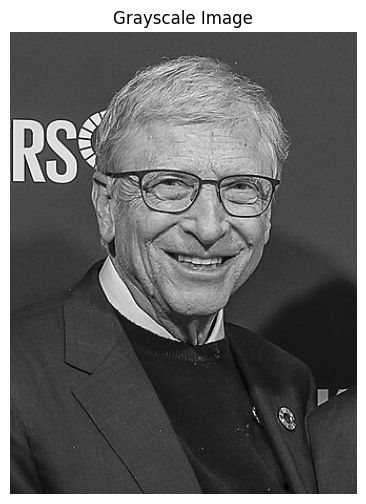

In [8]:
import matplotlib.pyplot as plt
from skimage import color, io

# Load the image
image = io.imread('E:/Notebook/start-end-ML/bill.jpg')

# Convert to grayscale
gray_image = color.rgb2gray(image)

# Display the image
plt.figure(figsize=(6,6))
plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()


## Extract Features Using HOG
HOG extracts gradient-based features, useful for object detection (e.g., face recognition, license plate detection).

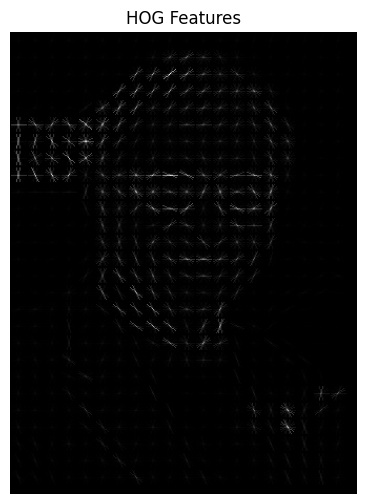

In [9]:
from skimage.feature import hog

# Extract HOG features
features, hog_image = hog(gray_image, pixels_per_cell=(16, 16),
                          cells_per_block=(2, 2), visualize=True)

# Display the HOG features
plt.figure(figsize=(6,6))
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Features")
plt.axis('off')
plt.show()


## Train a Classifier with Extracted Features
Let's assume we have a dataset of dog vs. cat images. We'll extract HOG features and train an ML model.

In [10]:
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Fake dataset (HOG features of images)
X = np.random.rand(100, len(features))  # 100 images with HOG feature vectors
y = np.random.choice([0, 1], size=100)  # Binary labels: 0 = cat, 1 = dog

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an SVM model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 0.45


# Example:Time Series

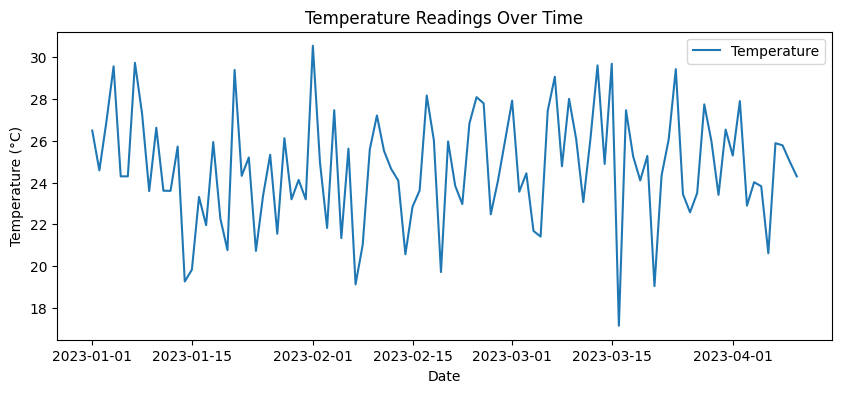

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a sample time-series dataset (Temperature readings)
np.random.seed(42)
date_rng = pd.date_range(start='2023-01-01', periods=100, freq='D')
temperature = np.random.normal(loc=25, scale=3, size=(100,))  # Random temp values

df = pd.DataFrame({'Date': date_rng, 'Temperature': temperature})
df.set_index('Date', inplace=True)

# Plot the time series data
plt.figure(figsize=(10,4))
plt.plot(df.index, df['Temperature'], label='Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Readings Over Time')
plt.legend()
plt.show()


## Extract Features from Time-Series Data
We'll extract:
- ✅ Rolling Mean (Trend)
- ✅ Rolling Variance (Volatility)
- ✅ Lag Features (Past Observations)
- ✅ Fourier Transform (Frequency Patterns)

### 📌 A) Rolling Statistics (Trend & Volatility)
We calculate the moving average and variance to analyze trends.

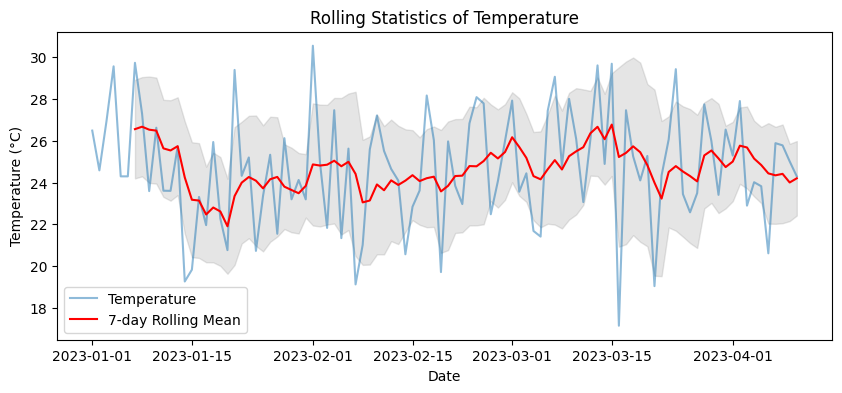

In [13]:
df['Rolling_Mean'] = df['Temperature'].rolling(window=7).mean()
df['Rolling_Std'] = df['Temperature'].rolling(window=7).std()

# Plot rolling statistics
plt.figure(figsize=(10,4))
plt.plot(df['Temperature'], label='Temperature', alpha=0.5)
plt.plot(df['Rolling_Mean'], label='7-day Rolling Mean', color='red')
plt.fill_between(df.index, df['Rolling_Mean'] - df['Rolling_Std'], 
                 df['Rolling_Mean'] + df['Rolling_Std'], color='gray', alpha=0.2)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Rolling Statistics of Temperature')
plt.legend()
plt.show()


**📌 Why?**

- Rolling mean captures long-term trends.

- Rolling standard deviation detects volatility (temperature fluctuations).

### 📌 B) Lag Features (Past Observations as Features)
We create new features from past values (e.g., yesterday's temperature).

In [14]:
df['Temp_Lag_1'] = df['Temperature'].shift(1)  # Yesterday's temperature
df['Temp_Lag_7'] = df['Temperature'].shift(7)  # Last week's temperature

df.head(10)

,Temperature,Rolling_Mean,Rolling_Std,Temp_Lag_1,Temp_Lag_7
Date,,,,,
2023-01-01,26.490142,NaN,NaN,NaN,NaN
2023-01-02,24.585207,NaN,NaN,26.490142,NaN
2023-01-03,26.943066,NaN,NaN,24.585207,NaN
2023-01-04,29.569090,NaN,NaN,26.943066,NaN
2023-01-05,24.297540,NaN,NaN,29.569090,NaN
2023-01-06,24.297589,NaN,NaN,24.297540,NaN
2023-01-07,29.737638,26.560039,2.360814,24.297589,NaN
2023-01-08,27.302304,26.676062,2.376710,29.737638,26.490142
2023-01-09,23.591577,26.534115,2.546037,27.302304,24.585207


**📌 Why?**

- Useful for predicting future values using past patterns.

- Often used in stock price and weather forecasting.



### C) Fourier Transform (Extracting Frequency Patterns)
The Fast Fourier Transform (FFT) extracts dominant cycles.

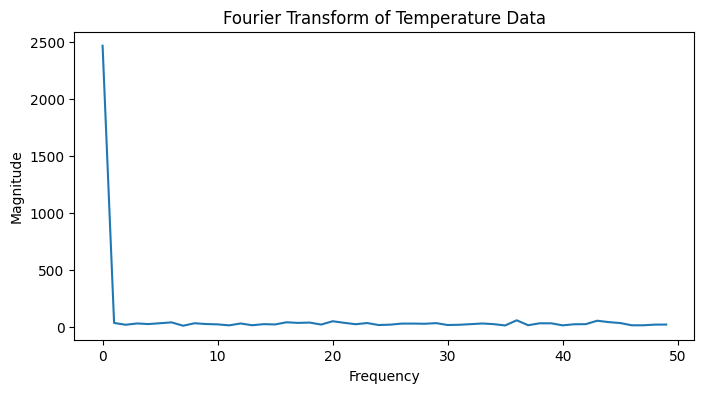

In [15]:
from numpy.fft import fft

# Apply FFT to temperature data
fft_features = fft(df['Temperature'])
fft_magnitude = np.abs(fft_features)

# Plot FFT
plt.figure(figsize=(8, 4))
plt.plot(fft_magnitude[:50])  # Show first 50 frequencies
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Fourier Transform of Temperature Data")
plt.show()


**📌 Why?**

- FFT detects seasonal patterns (e.g., weekly temperature changes).

- Useful for demand forecasting, ECG signals, and speech recognition.



## Feature Extraction with tsfresh (Automated Approach)
Instead of manually creating features, we can use tsfresh, a library for automated feature extraction.

In [16]:
from tsfresh import extract_features

# Convert the dataset into a format required by tsfresh
df['id'] = 1  # Required for tsfresh
features = extract_features(df, column_id='id', column_sort='Date')

# Display extracted features
features.head()

ValueError: Column must not contain NaN values: Rolling_Mean

**📌 Why?**

- Extracts statistical & frequency-based features automatically.

- Saves time for complex time-series datasets.

## Train an ML Model with Extracted Features
Let's train a Random Forest Regressor to predict future temperatures.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Drop NaN values
df.dropna(inplace=True)

# Select features and target
X = df[['Rolling_Mean', 'Rolling_Std', 'Temp_Lag_1', 'Temp_Lag_7']]
y = df['Temperature']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')


#  Feature Extraction from Stock Price Data (Real-World Example)
We’ll extract features from a real-world stock price dataset and use them to train an ML model for stock price prediction.

In [19]:
import yfinance as yf

# Download stock price data for Apple (AAPL)
df = yf.download('AAPL', start='2022-01-01', end='2024-01-01', interval='1d')

# Display the first few rows
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.879944,179.734993,174.653904,174.771835,104487900
2022-01-04,176.609665,179.793951,176.039637,179.489285,99310400
2022-01-05,171.911880,177.071596,171.636697,176.521228,94537600
2022-01-06,169.042084,172.285336,168.688274,169.730043,96904000
2022-01-07,169.209152,171.145275,168.088758,169.916771,86709100


## Visualize Stock Prices

**📌 Why?**

- Helps identify trends, spikes, and dips.

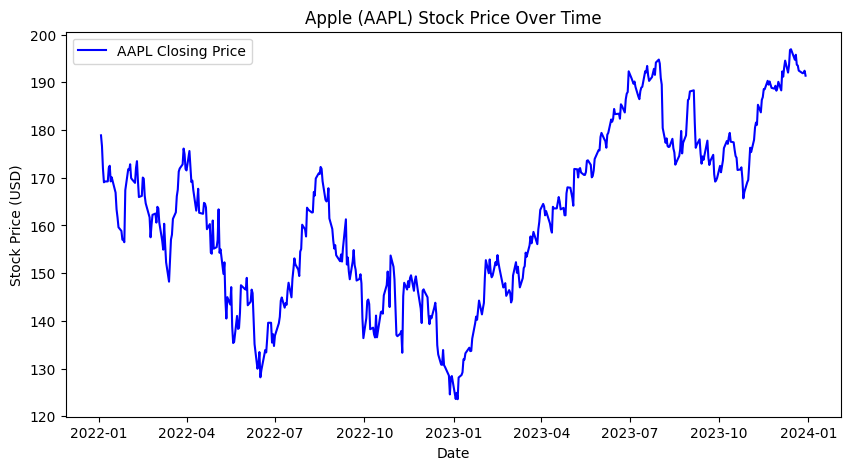

In [20]:
import matplotlib.pyplot as plt

# Plot closing prices
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Close'], label='AAPL Closing Price', color='blue')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.title('Apple (AAPL) Stock Price Over Time')
plt.legend()
plt.show()


## Extract Features from Stock Data
We will extract:
- ✅ Moving Averages (Trend Indicator)
- ✅ Price Volatility (Risk Indicator)
- ✅ Relative Strength Index (Momentum Indicator)
- ✅ Lag Features (Past Prices as Inputs)

### 📌 A) Moving Averages (Short-Term & Long-Term Trend)

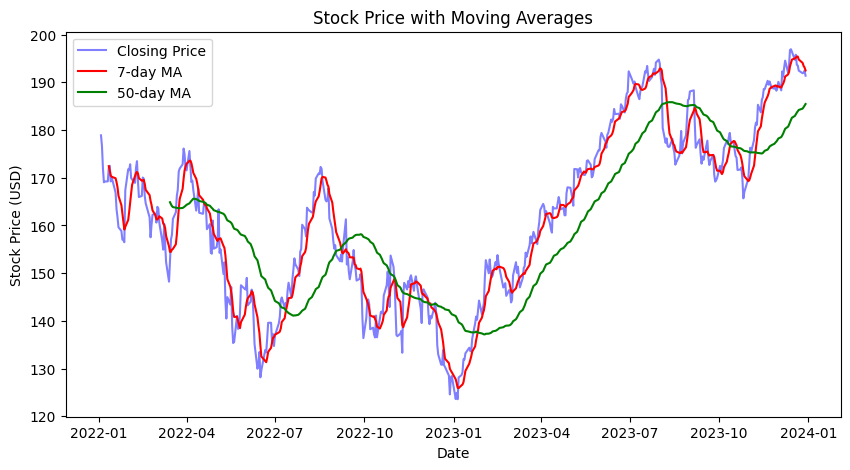

In [21]:
# Short-term (7-day) and long-term (50-day) moving averages
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# Plot moving averages
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Closing Price', color='blue', alpha=0.5)
plt.plot(df['MA_7'], label='7-day MA', color='red')
plt.plot(df['MA_50'], label='50-day MA', color='green')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.title('Stock Price with Moving Averages')
plt.legend()
plt.show()


**📌 Why?**

Helps detect trends:

- If MA_7 > MA_50 → Bullish trend (price rising).

- If MA_7 < MA_50 → Bearish trend (price falling).

### 📌 B) Volatility Indicator (Rolling Standard Deviation)

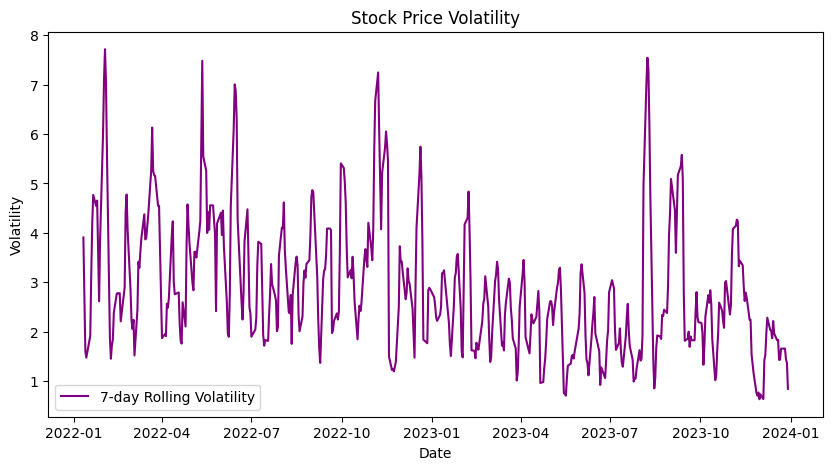

In [22]:
# Rolling standard deviation (volatility)
df['Volatility'] = df['Close'].rolling(window=7).std()

# Plot volatility
plt.figure(figsize=(10,5))
plt.plot(df['Volatility'], label='7-day Rolling Volatility', color='purple')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title('Stock Price Volatility')
plt.legend()
plt.show()


**📌 Why?**

- Measures risk (high volatility means frequent price swings).

- Used in risk management and algorithmic trading.



### 📌 C) Relative Strength Index (RSI - Momentum Indicator)
RSI measures overbought (above 70) or oversold (below 30) conditions.

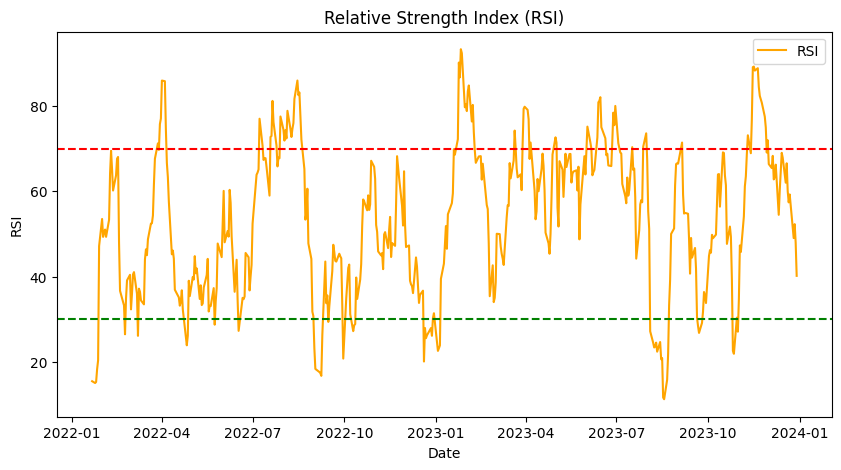

In [23]:
def compute_rsi(data, window=14):
    delta = data.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Compute RSI
df['RSI'] = compute_rsi(df['Close'])

# Plot RSI
plt.figure(figsize=(10,5))
plt.plot(df['RSI'], label='RSI', color='orange')
plt.axhline(70, linestyle='--', color='red')  # Overbought level
plt.axhline(30, linestyle='--', color='green')  # Oversold level
plt.xlabel('Date')
plt.ylabel('RSI')
plt.title('Relative Strength Index (RSI)')
plt.legend()
plt.show()


**📌 Why?**

- RSI > 70 → Stock is overbought (possible price drop).

- RSI < 30 → Stock is oversold (possible price rise).

### 📌 D) Lag Features (Past Price as Predictors)

In [24]:
df['Close_Lag_1'] = df['Close'].shift(1)  # Yesterday's closing price
df['Close_Lag_7'] = df['Close'].shift(7)  # Last week's closing price
df.dropna(inplace=True)  # Drop NaN values from shifting

print(df[['Close', 'Close_Lag_1', 'Close_Lag_7']].head(10))


Price            Close Close_Lag_1 Close_Lag_7
Ticker            AAPL                        
Date                                          
2022-03-15  152.617065  148.218338  160.568222
2022-03-16  157.045288  152.617065  156.759949
2022-03-17  158.058899  157.045288  154.929611
2022-03-18  161.365311  158.058899  160.351761
2022-03-21  162.742996  161.365311  155.992386
2022-03-22  166.128159  162.742996  152.262802
2022-03-23  167.495972  166.128159  148.218338
2022-03-24  171.294449  167.495972  152.617065
2022-03-25  171.934082  171.294449  157.045288
2022-03-28  172.800003  171.934082  158.058899


**📌 Why?**

- Helps time-series forecasting models learn past price patterns.

## Train an ML Model to Predict Stock Prices
We’ll use a Random Forest Regressor to predict the next day's closing price.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Select features and target
features = ['MA_7', 'MA_50', 'Volatility', 'RSI', 'Close_Lag_1', 'Close_Lag_7']
target = 'Close'

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predict stock price
y_pred = model.predict(X_test)

# Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f} USD')


Mean Absolute Error: 2.02 USD


e:\notebook\notebook_env\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
